## ANNNI MODEL LOOPED J2 VALUES USING ReverseEstimatorGradient

In [1]:

import os
import time
import numpy as np
import scipy.sparse.linalg as spla
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.gradients import ReverseEstimatorGradient
from scipy.optimize import minimize

os.chdir(r"C:\qiskit-project")

In [ ]:
# 1. Hamiltonian + ansatz

def build_annni_ham(N, J1, J2, h, bc="periodic"):
    """H = -J1*sum ZZ(NN) + J2*sum ZZ(NNN) + h*sum X. Pass J1 POSITIVE""""
    sl = []
    for i in range(N - 1):
        sl.append(("ZZ", [i, i + 1], -J1))
    if bc == "periodic":
        sl.append(("ZZ", [N - 1, 0], -J1))
    for i in range(N - 2):
        sl.append(("ZZ", [i, i + 2], J2))
    if bc == "periodic":
        sl.append(("ZZ", [N - 2, 0], J2))
        sl.append(("ZZ", [N - 1, 1], J2))
    for i in range(N):
        sl.append(("X", [i], h))
    return SparsePauliOp.from_sparse_list(sl, num_qubits=N)


def build_HA(N, bc="periodic"):
    """dH/dJ2  bare NNN ZZ sum, for the Hellmann-Feynman derivative."""
    sl = []
    for i in range(N - 2):
        sl.append(("ZZ", [i, i + 2], 1.0))
    if bc == "periodic":
        sl.append(("ZZ", [N - 2, 0], 1.0))
        sl.append(("ZZ", [N - 1, 1], 1.0))
    return SparsePauliOp.from_sparse_list(sl, num_qubits=N)


def build_ansatz(N, bc="periodic", reps=2):
    
    r1 = [[i, i + 1] for i in range(0, N - 1, 2)]
    r2 = [[i, i + 1] for i in range(1, N - 1, 2)]
    if bc == "periodic":
        r2 = r2 + [[N - 1, 0]]
    return EfficientSU2(num_qubits=N, su2_gates=["ry", "rz"], entanglement=r1 + r2, reps=reps)

In [ ]:

# 2. Optimization helpers exact gradient, multi-start


def make_cost_and_jac(ansatz, H, estimator, gradient):
    def cost(params):
        return float(estimator.run([(ansatz, H, params)]).result()[0].data.evs)

    def jac(params):
        return np.array(gradient.run([ansatz], [H], [params]).result().gradients[0])

    return cost, jac


def run_one(cost, jac, x0, opt_options):
    res = minimize(fun=cost, x0=x0, jac=jac, method="L-BFGS-B", options=opt_options)
    return float(res.fun), np.array(res.x, copy=True), res.nfev, bool(res.success)


def multi_start_optimize(cost, jac, warm_seed, num_params, n_restarts, opt_options, seed_base):
    
    candidates = [("warm-start", warm_seed)]
    for r in range(n_restarts):
        x0 = np.random.RandomState(seed_base + r).uniform(-np.pi, np.pi, num_params)
        candidates.append((f"random-{r}", x0))

    best = None  # (energy, params, label, nfev)
    total_nfev = 0
    for label, x0 in candidates:
        e, p, nfev, _ = run_one(cost, jac, x0, opt_options)
        total_nfev += nfev
        if best is None or e < best[0]:
            best = (e, p, label, nfev)
    return best[0], best[1], best[2], total_nfev

In [ ]:
# 3. Problem setup

N, J1, h, BC = 12, 1.0, 0.1, "periodic"
J2_START, J2_STOP, J2_STEP = 0.40, 0.60, 0.01
REPS = 2

RESET_ZONE = (0.45, 0.57)
N_RESTARTS = 4         
RESET_TOL = 1e-6

OPT_OPTIONS = {"maxiter": 150, "ftol": 1e-9, "gtol": 1e-6, "maxls": 50}

j2_values = np.round(np.arange(J2_START, J2_STOP + 1e-9, J2_STEP), 4)

ansatz = build_ansatz(N, bc=BC, reps=REPS)
HA = build_HA(N, bc=BC)
HA_sparse = HA.to_matrix(sparse=True)
num_params = ansatz.num_parameters
estimator = StatevectorEstimator()
gradient = ReverseEstimatorGradient()

print(f"Ansatz: reps={REPS}, {num_params} parameters. Scanning {len(j2_values)} points.")
print(f"Multi-start reset zone: J2/J1 in [{RESET_ZONE[0]}, {RESET_ZONE[1]}], "
      f"{1+N_RESTARTS} candidates/point there, exact gradients throughout.\n")

In [ ]:
# 4. Sweep

results = {k: [] for k in ["j2", "energy_vqe", "denergy_dj2_vqe", "energy_exact",
                           "denergy_dj2_exact", "n_evaluations", "wall_time_s",
                           "strategy", "params"]}

prev_best_params = None
t_start = time.time()

for k, J2 in enumerate(j2_values):
    H = build_annni_ham(N, J1=J1, J2=J2, h=h, bc=BC)
    cost, jac = make_cost_and_jac(ansatz, H, estimator, gradient)

    is_reset_point = RESET_ZONE[0] - RESET_TOL <= J2 <= RESET_ZONE[1] + RESET_TOL

    if prev_best_params is None:
        warm_seed = np.random.RandomState(50).uniform(-0.5, 0.5, num_params)
        is_reset_point = True  # no warm start available yet -- treat as reset
    else:
        warm_seed = prev_best_params.copy()

    t0 = time.time()
    if is_reset_point:
        best_energy, best_params, strategy, n_eval = multi_start_optimize(
            cost, jac, warm_seed, num_params, N_RESTARTS, OPT_OPTIONS, seed_base=1000 + 10 * k
        )
    else:
        best_energy, best_params, n_eval, _ = run_one(cost, jac, warm_seed, OPT_OPTIONS)
        strategy = "warm-start"
    dt = time.time() - t0

    dE_dJ2_vqe = float(estimator.run([(ansatz, HA, best_params)]).result()[0].data.evs)

    H_sparse = H.to_matrix(sparse=True)
    evals, evecs = spla.eigsh(H_sparse, k=1, which="SA")
    exact_energy = float(evals[0])
    psi0 = evecs[:, 0]
    dE_dJ2_exact = float(np.real(psi0.conj() @ (HA_sparse @ psi0)))

    for key, val in zip(results.keys(),
                         [J2, best_energy, dE_dJ2_vqe, exact_energy, dE_dJ2_exact,
                          n_eval, dt, strategy, best_params]):
        results[key].append(val)

    tag = "RESET" if is_reset_point else "warm "
    print(f"[{k+1:2d}/{len(j2_values)}] J2/J1={J2:.3f} [{tag}] | "
          f"E_vqe={best_energy:.6f} (exact {exact_energy:.6f}, err {abs(best_energy-exact_energy):.2e}) | "
          f"dE/dJ2_vqe={dE_dJ2_vqe:.6f} (exact {dE_dJ2_exact:.6f}) | "
          f"winner={strategy:12s} evals={n_eval:5d} | {dt:6.1f}s")

    prev_best_params = best_params

print(f"\nTotal sweep time: {time.time()-t_start:.1f}s")



# 5. Save


out_file = f"annni_N{N}_h{h}_{BC}_reps{REPS}_ideal.npz"
np.savez(out_file,
         j2=np.array(results["j2"]), energy_vqe=np.array(results["energy_vqe"]),
         denergy_dj2_vqe=np.array(results["denergy_dj2_vqe"]),
         energy_exact=np.array(results["energy_exact"]),
         denergy_dj2_exact=np.array(results["denergy_dj2_exact"]),
         n_evaluations=np.array(results["n_evaluations"]), wall_time_s=np.array(results["wall_time_s"]),
         strategy=np.array(results["strategy"]), params=np.array(results["params"]),
         reset_zone=np.array(RESET_ZONE), J1=J1, h=h, N=N, bc=BC, reps=REPS)
print(f"Saved to: {os.path.abspath(out_file)}")


saved annni_scan_final.png
max energy error: 0.1563 at J2/J1=0.49


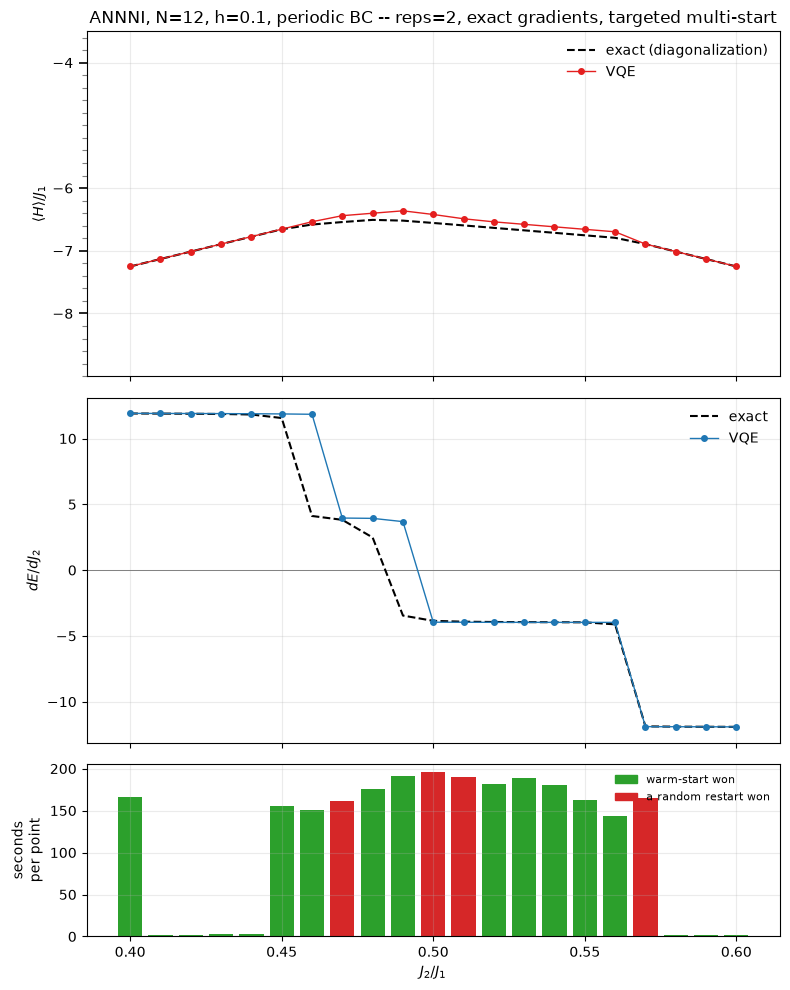

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FixedLocator

d = np.load("annni_tno__scan_N12_h0.1_periodic_reps2_exactgrad.npz")

j2 = d["j2"]
E_vqe, E_exact = d["energy_vqe"], d["energy_exact"]
dE_vqe, dE_exact = d["denergy_dj2_vqe"], d["denergy_dj2_exact"]
strategy = d["strategy"]
wall_time = d["wall_time_s"]
N, h, bc = int(d["N"]), float(d["h"]), str(d["bc"])

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

ax = axes[0]
ax.plot(j2, E_exact, "k--", lw=1.5, label="exact (diagonalization)")
ax.plot(j2, E_vqe, "o-", color="#e41f1f", ms=4, lw=1, label="VQE")
ax.set_ylabel(r"$\langle H \rangle / J_1$")
ax.set_title(f"ANNNI, N={N}, h={h}, {bc} BC -- reps=2, exact gradients, targeted multi-start")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

# 
ax.yaxis.set_major_locator(FixedLocator([-8, -7, -6, -4]))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))  # 5 minor divisions between major ticks
ax.set_ylim(-9.0, -3.5)

# Configure tick appearance for clear visibility
ax.tick_params(axis='y', which='major', length=6, width=1.2)
ax.tick_params(axis='y', which='minor', length=3.5, width=0.8, color='gray')

ax = axes[1]
ax.axhline(0, color="grey", lw=0.7)
ax.plot(j2, dE_exact, "k--", lw=1.5, label="exact")
ax.plot(j2, dE_vqe, "o-", color="#1f77b4", ms=4, lw=1, label="VQE")
ax.set_ylabel(r"$dE/dJ_2$")
ax.legend(frameon=False)
ax.grid(alpha=0.25)

# colour bars by which candidate won: warm-start vs a random restart
ax = axes[2]
colors = ["#2ca02c" if s == "warm-start" else "#d62728" for s in strategy]
ax.bar(j2, wall_time, width=0.008, color=colors)
ax.set_ylabel("seconds\nper point")
ax.set_xlabel(r"$J_2/J_1$")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ca02c", label="warm-start won"),
                   Patch(color="#d62728", label="a random restart won")],
          frameon=False, fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("annni_scan_final.png", dpi=150)
print("saved annni_scan_final.png")
print(f"max energy error: {np.max(np.abs(E_vqe-E_exact)):.4f} at J2/J1={j2[np.argmax(np.abs(E_vqe-E_exact))]:.2f}")